In [2]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import torch
from gencase import *
from util import visualize, sampleParticles, generateInitialVariables, SamplingScheme
from sample import smoothState, addNoise, populateCGrid, populateUGrid, smoothValues
from util import plotState, plotInitialState
from simulation import runSimulation
from util import getCurrentTimestamp
from argparse import ArgumentParser

parser = ArgumentParser()

parser.add_argument('--nx', type=int, default=128, help='Number of grid points in one dimension')
parser.add_argument('--sampling', type=str, default='regular', help='Particle sampling scheme: regular, regular_jittered, glass, optimal, random')

parser.add_argument('--dt', type=float, default=0.0025, help='Time step size')
parser.add_argument('--nIter', type=int, default=1024, help='Number of iterations')

parser.add_argument('--uMagnitudes', type=float, nargs='*', default=[10], help='List of possible wave speeds for obstacles')
parser.add_argument('--uRandomMagnitude', action='store_true', help='Enable random magnitudes for sources')
parser.add_argument('--uRandomMin', type=float, default=-10.0, help='Minimum magnitude for sources when uRandomMagnitude is enabled')
parser.add_argument('--uRandomMax', type=float, default=10.0, help='Maximum magnitude for sources when uRandomMagnitude is enabled')

parser.add_argument('--smoothICs', action='store_true', help='Enable smoothing of initial conditions')
parser.add_argument('--smoothIters', type=int, default=4, help='Number of smoothing iterations for initial conditions')

parser.add_argument('--plotInterval', type=int, default=10, help='Plotting interval')
parser.add_argument('--export', action='store_true', help='Whether to export simulation data')
parser.add_argument('--exportImages', action='store_true', help='Whether to export simulation images')

parser.add_argument('--filePrefix', type=str, default='waveEqn', help='Prefix for output files')
parser.add_argument('--verbose', action='store_true', help='Enable verbose output')

parser.add_argument('--domainBox', action='store_true', help='Enable domain boundary box')
parser.add_argument('--domainDamping', action='store_true', help='Enable domain boundary damping')

parser.add_argument('--enableNoise', action='store_true', help='Enable noise addition to initial conditions')
parser.add_argument('--noiseType', type=str, default='perlin', help='Type of noise to add: perlin, uniform, normal')
parser.add_argument('--noiseAmplitude', type=float, default=0.02, help='Amplitude of noise to add to initial conditions')
parser.add_argument('--noiseSmoothIter', type=int, default=4, help='Number of smoothing iterations for noise')
parser.add_argument('--noiseSeed', type=int, default=42, help='Random seed for noise generation')

parser.add_argument('--boundarySpeed', type=float, default=0.01, help='Wave speed at boundaries')
parser.add_argument('--obstacleSpeeds', type=float, nargs='*', default=[0.5], help='List of possible wave speeds for obstacles')


parser.add_argument('--defaultSpeed', type=float, default=1.0, help='Default wave speed in the medium')
parser.add_argument('--randomObstacleSpeed', action='store_true', help='Enable random wave speeds for obstacles')
parser.add_argument('--obstacleSpeedMin', type=float, default=0.3, help='Minimum wave speed for obstacles when randomObstacleSpeed is enabled')
parser.add_argument('--obstacleSpeedMax', type=float, default=0.7, help='Maximum wave speed for obstacles when randomObstacleSpeed is enabled')

parser.add_argument('--figureDpi --dt=0.01', type=int, default=200, help='DPI for saved figures')

import shlex
cmdArgs = '--verbose'
splitArgs = shlex.split(cmdArgs)

args = parser.parse_args(splitArgs)

In [3]:

verbose = args.verbose
if verbose:
    print("Simulation Configuration:")
    for arg, value in vars(args).items():
        print(f'{arg}: {value}')

# exit()

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
if verbose:
    print(f'Using device: {device}')

plotInterval = args.plotInterval
nIter = args.nIter
dt = args.dt
nx = args.nx
# uMagnitude = args.uMagnitude
sampling = args.sampling
samplingScheme = None
export = args.export
timestamp = getCurrentTimestamp()


for scheme in SamplingScheme:
    if scheme.name == sampling:
        samplingScheme = scheme
        if verbose:
            print(f'Using sampling scheme: {samplingScheme.name}')
        break
if samplingScheme is None:
    raise ValueError(f'Unknown sampling scheme: {sampling}')

prefix = f'{args.filePrefix}_{nx}_{sampling}'
os.makedirs('output', exist_ok=True)
folderName = f'{prefix}_{timestamp}'
os.makedirs(f'output/{folderName}', exist_ok=True)
if verbose:
    print(f'Output folder: output/{folderName}')

config, domain, device, dtype, kernel = generateInitialVariables(
    nx, device = device
)
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4
integrator = getIntegrator(config['integrationScheme'])
if verbose:
    print(f'Using integrator: {config["integrationScheme"].name}')


Simulation Configuration:
nx: 128
sampling: regular
dt: 0.0025
nIter: 1024
uMagnitudes: [10]
uRandomMagnitude: False
uRandomMin: -10.0
uRandomMax: 10.0
smoothICs: False
smoothIters: 4
plotInterval: 10
export: False
exportImages: False
filePrefix: waveEqn
verbose: True
domainBox: False
domainDamping: False
enableNoise: False
noiseType: perlin
noiseAmplitude: 0.02
noiseSmoothIter: 4
noiseSeed: 42
boundarySpeed: 0.01
obstacleSpeeds: [0.5]
defaultSpeed: 1.0
randomObstacleSpeed: False
obstacleSpeedMin: 0.3
obstacleSpeedMax: 0.7
figureDpi __dt=0.01: 200
Using device: cuda:0
Using sampling scheme: regular
Output folder: output/waveEqn_128_regular_2026-02-12_09-18-28


0it [00:00, ?it/s]

Using integrator: rungeKutta4


In [4]:
################################################################################
#                             Particle Generation                              #
################################################################################

particles, numNeighbors, counter = sampleParticles(nx, scheme=samplingScheme)
particleState = BasicState(particles.positions, particles.supports, particles.masses, particles.densities, torch.zeros_like(particles.positions), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.zeros(particles.positions.shape[0], device = device, dtype = torch.int64), torch.arange(particles.positions.shape[0], device = device), particles.positions.shape[0])
neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
particleState.numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

0it [00:00, ?it/s]

In [5]:
################################################################################
#                                Boundary Setup                                #
################################################################################

uGrid, vGrid, cGrid, dampGrid, uSourceGrid, cSourceGrid = genInitial(
    particleState, config,
    nx,
    domainBox = args.domainBox,
    domainDamping = args.domainDamping,
)

In [6]:

uGrid, vGrid, cGrid, dampGrid, uSourceGrid, cSourceGrid, sourceCounter = genCase_06(
    particleState, config,
    nx,
    radii = 0.15,
    rotations = np.pi/2,
    shapes = 'circle',
    domainBox = False,
    domainDamping = False,
    randomRadius = False,
    randomRotation = False,
    radiusRange = (0.03, 0.1),
)


In [7]:
'''
For our dataset we want to have a few different initial conditions.
These are:
- A single Gaussian bell in the center of the domain
- Two Gaussian bells, one in the left half of the domain and one in the right half
- A Gaussian bell in the center with a random noise pattern superimposed on top
- A random noise pattern with no Gaussian bell
- A vertical line source in the center of the domain
- A horizontal line source in the center of the domain
- A circular ring source in the center of the domain
- A square source in the center of the domain
- Two vertical line sources, one in the left half of the domain and one in the right half
- Two horizontal line sources, one in the top half of the domain and one in the bottom half
- Two circular ring sources, one in the left half of the domain and one in the right half
- Two square sources, one in the top half of the domain and one in the bottom half

All of them have no boundaries (case 01) and constant wave speed c = 1 everywhere.
'''

'\nFor our dataset we want to have a few different initial conditions.\nThese are:\n- A single Gaussian bell in the center of the domain\n- Two Gaussian bells, one in the left half of the domain and one in the right half\n- A Gaussian bell in the center with a random noise pattern superimposed on top\n- A random noise pattern with no Gaussian bell\n- A vertical line source in the center of the domain\n- A horizontal line source in the center of the domain\n- A circular ring source in the center of the domain\n- A square source in the center of the domain\n- Two vertical line sources, one in the left half of the domain and one in the right half\n- Two horizontal line sources, one in the top half of the domain and one in the bottom half\n- Two circular ring sources, one in the left half of the domain and one in the right half\n- Two square sources, one in the top half of the domain and one in the bottom half\n\nAll of them have no boundaries (case 01) and constant wave speed c = 1 everyw

In [44]:
uGrid, vGrid, cGrid, dampGrid, uSourceGrid, cSourceGrid = genInitial(
    particleState, config,
    nx,
    domainBox = False,
    domainDamping = False,
)

backgroundC = 1
gaussianSourceRadius = 0.2
circularSourceInnerRadius = 0.15
circularSourceOuterRadius = 0.25
squareSourceHalfSize = 0.15
lineSourceWidth = 0.05
uMagnitude = 10

L = domain.max - domain.min 
domainCenter = domain.min + 0.5 * L
# print(domainCenter)
topOffset = domainCenter + torch.tensor([0, 0.25], device = device, dtype = dtype) * L
bottomOffset = domainCenter + torch.tensor([0, -0.25], device = device, dtype = dtype) * L
leftOffset = domainCenter + torch.tensor([-0.25, 0], device = device, dtype = dtype) * L
rightOffset = domainCenter + torch.tensor([0.25, 0], device = device, dtype = dtype) * L
# print(topOffset, bottomOffset, leftOffset, rightOffset)

def genGaussianBell(positions, center, radius, magnitude):
    # Compute the distance from each particle to the center
    distances = torch.norm(positions - center, dim=1)
    # Compute the Gaussian bell values
    bell = magnitude * torch.exp(-0.5 * (distances / radius) ** 2)
    return bell

def genCircle(positions, center, radius, magnitude):
    distances = torch.norm(positions - center, dim=1)
    circle = torch.where(distances <= radius, magnitude, torch.zeros_like(distances))
    return circle

In [64]:
# Case 01: Single Gaussian bell in the center of the domain
uGrid = genCircle(particleState.positions, domainCenter, gaussianSourceRadius, uMagnitude)

# Case 02: Two Gaussian bells, one in the left half of the domain and one in the right half
uGrid = genCircle(particleState.positions, leftOffset, gaussianSourceRadius, uMagnitude) - genCircle(particleState.positions, rightOffset, gaussianSourceRadius, uMagnitude)

# Case 03: A Gaussian bell in the center with a random noise pattern superimposed on top
uGrid = genCircle(particleState.positions, domainCenter, gaussianSourceRadius, uMagnitude)

uGrid = addNoise(
    particleState, config, neighbors,
    uGrid, cSourceGrid,
    noiseAmplitude = 0.25, uMagnitude = uMagnitude,
    noiseType = 'uniform',
    smoothIter = 1,
    seed = args.noiseSeed,
    octaves = 4,
    baseFrequency = 4,
)

# Case 04: A random noise pattern with no Gaussian bell
uGrid = addNoise(
    particleState, config, neighbors,
    torch.zeros_like(particleState.positions[:,0]), cSourceGrid,
    noiseAmplitude = 1, uMagnitude = uMagnitude,
    noiseType = 'uniform',
    smoothIter = 0,
    seed = args.noiseSeed,
    octaves = 4,
    baseFrequency = 4,
)

# Case 05: A vertical line source in the center of the domain
uGrid = torch.where(torch.abs(particleState.positions[:,0] - domainCenter[0]) < lineSourceWidth, uMagnitude, torch.zeros_like(particleState.positions[:,0]))

# Case 06: A horizontal line source in the center of the domain
uGrid = torch.where(torch.abs(particleState.positions[:,1] - domainCenter[1]) < lineSourceWidth, uMagnitude, torch.zeros_like(particleState.positions[:,0]))

# Case 07: A circular ring source in the center of the domain
uGrid = genCircle(particleState.positions, domainCenter, circularSourceOuterRadius, uMagnitude) - genCircle(particleState.positions, domainCenter, circularSourceInnerRadius, uMagnitude)

# Case 08: A square source in the center of the domain
uGrid = torch.where(
    (torch.abs(particleState.positions[:,0] - domainCenter[0]) < squareSourceHalfSize) &
    (torch.abs(particleState.positions[:,1] - domainCenter[1]) < squareSourceHalfSize),
    uMagnitude, torch.zeros_like(particleState.positions[:,0])
)

# Case 09: Two vertical line sources, one in the left half of the domain and one in the right half
uGrid = torch.where(
    (torch.abs(particleState.positions[:,0] - leftOffset[0]) < lineSourceWidth) |
    (torch.abs(particleState.positions[:,0] - rightOffset[0]) < lineSourceWidth),
    uMagnitude, torch.zeros_like(particleState.positions[:,0])
)
uGrid[particleState.positions[:,1] < domainCenter[1]] *= -1

# Case 10: Two horizontal line sources, one in the top half of the domain and one in the bottom half
uGrid = torch.where(
    (torch.abs(particleState.positions[:,1] - topOffset[1]) < lineSourceWidth) |
    (torch.abs(particleState.positions[:,1] - bottomOffset[1]) < lineSourceWidth),
    uMagnitude, torch.zeros_like(particleState.positions[:,0])
)
uGrid[particleState.positions[:,0] >= domainCenter[0]] *= -1

# Case 11: Two circular ring sources, one in the left half of the domain and one in the right half
uGrid = genCircle(particleState.positions, leftOffset, circularSourceOuterRadius, uMagnitude) - genCircle(particleState.positions, leftOffset, circularSourceInnerRadius, uMagnitude) + genCircle(particleState.positions, rightOffset, circularSourceOuterRadius, uMagnitude) - genCircle(particleState.positions, rightOffset, circularSourceInnerRadius, uMagnitude) 
uGrid[particleState.positions[:,0] >= domainCenter[0]] *= -1

# Case 12: Two square sources, one in the top half of the domain and one in the bottom half
uGrid = torch.where(
    ((torch.abs(particleState.positions[:,0] - topOffset[0]) < squareSourceHalfSize) &
     (torch.abs(particleState.positions[:,1] - topOffset[1]) < squareSourceHalfSize)) |
    ((torch.abs(particleState.positions[:,0] - bottomOffset[0]) < squareSourceHalfSize) &
     (torch.abs(particleState.positions[:,1] - bottomOffset[1]) < squareSourceHalfSize)),
    uMagnitude, torch.zeros_like(particleState.positions[:,0])
)
uGrid[particleState.positions[:,1] < domainCenter[1]] *= -1


# normalize uGrid to be in the range [-1, 1]
uGrid = uGrid / torch.max(torch.abs(uGrid)) * uMagnitude
vGrid = torch.zeros_like(uGrid)

uPreSmoothMax = torch.max(uGrid).cpu().detach().item()
uPreSmoothMin = torch.min(uGrid).cpu().detach().item()

uGrid = smoothValues(
    uGrid,
    particleState,
    2, neighbors,
    config
)
# rescale uGrid back to original range after smoothing
# first scale to [0, 1]
# print(uPreSmoothMax, uPreSmoothMin, '---', torch.max(uGrid).cpu().detach().item(), torch.min(uGrid).cpu().detach().item())
uGrid = uGrid / (torch.max(uGrid) - torch.min(uGrid)) + 0.5
# print(torch.max(uGrid), torch.min(uGrid))
uGrid = uGrid * (uPreSmoothMax - uPreSmoothMin) + uPreSmoothMin
# print(torch.max(uGrid), torch.min(uGrid))


In [65]:

cSourceGrid = genBoundaryCase_01(
    particleState, config, nx,
    cSourceGrid,
    radii = [0.25, 0.25],
    rotations = [0.0, 0.0],
    offsets = [(0.0, 0.0), (0.0, 0.)],
    shapes = ['square', 'circle'],

    randomRadius = False,
    randomRotation = False,
    randomOffset = False,

    radiusRange = (0.03, 0.1),
    rotationRange = (0, 2*np.pi),
    offsetRange = ((-0.5, 0.5), (-0.5, 0.5))
)

In [66]:
################################################################################
#                           Initial Condition Setup                            #
################################################################################

if verbose:
    print("Setting up initial conditions...")

# uGrid = torch.zeros_like(uGrid)
# vGrid = torch.zeros_like(vGrid)

# uGrid = populateUGrid(uGrid, uSourceGrid,
#     sourceMagnitudes = args.uMagnitudes * sourceCounter if len(args.uMagnitudes) == 1 else args.uMagnitudes,
#     randomMagnitude = args.uRandomMagnitude,
#     magnitudeRange = (args.uRandomMin, args.uRandomMax)
# )

if args.smoothICs:
    if verbose:
        print("Smoothing initial conditions...")
    uGrid = smoothValues(
        uGrid,
        particleState,
        args.smoothIters, neighbors,
        config
    )

cGrid = populateCGrid(cGrid, cSourceGrid,
    boundaryC = args.boundarySpeed,
    obstacleC = args.obstacleSpeeds[0],
    defaultC = args.defaultSpeed,
    randomObstacleC = args.randomObstacleSpeed,
    obstacleCRange = (args.obstacleSpeedMin, args.obstacleSpeedMax)
)

uGrid = addNoise(
    particleState, config, neighbors,
    uGrid, cSourceGrid,
    noiseAmplitude = 0.0, uMagnitude = max(args.uMagnitudes),
    noiseType = args.noiseType,
    smoothIter = 1,
    seed = args.noiseSeed,
    octaves = 4,
    baseFrequency = 4,
)
# uGrid[particleState.positions[:,0] > 0] = 0.0

waveState = WaveEquationState(
    u = uGrid,
    v = vGrid,
    c = cGrid,
    damping = dampGrid,
)
smoothedState = smoothState(waveState, particleState, 0, neighbors, config)

waveSystem = WaveSystem(
    systemState = particleState,
    waveState = smoothedState,
    neighborhood = neighbors.get('noghost'),
    t = 0.0
)

Setting up initial conditions...


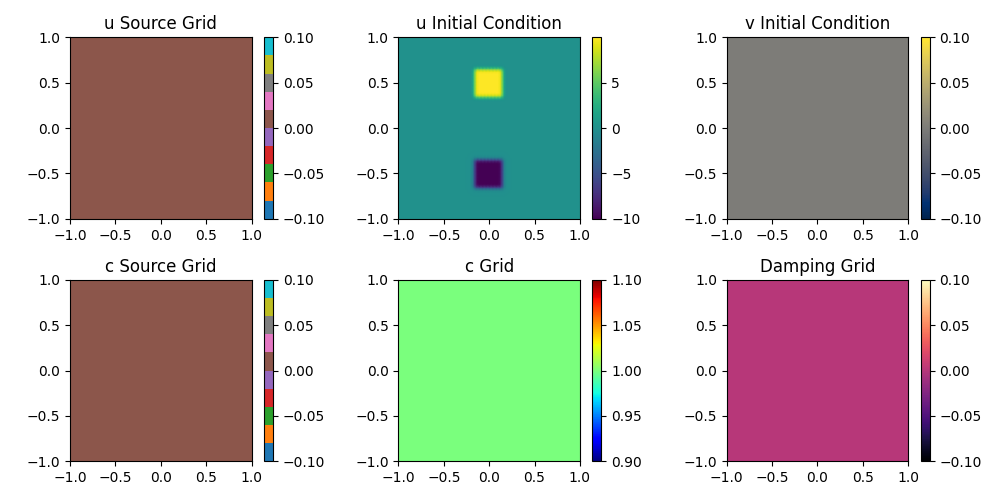

: 

In [ ]:
################################################################################
#                              Visualization Setup                             #
################################################################################

# fig, axis = visualize(particles, numNeighbors, counter)
# fig.savefig(f'output/{folderName}/initial_particles.png', dpi = args.figureDpi)

fig, axis = plotInitialState(
    particleState, config,
    uGrid, vGrid, cGrid, dampGrid,
    uSourceGrid, cSourceGrid
)
# fig.savefig(f'output/{folderName}/initial_fields.png', dpi = args.figureDpi)

Max wave speed: 1.0000
Max support radius: 0.0625
CFL number (based on dx): 1.2800 [dx=0.0156, dt=0.0200]
CFL number (based on hMax): 0.3200 [hMax=0.0625, dt=0.0200]


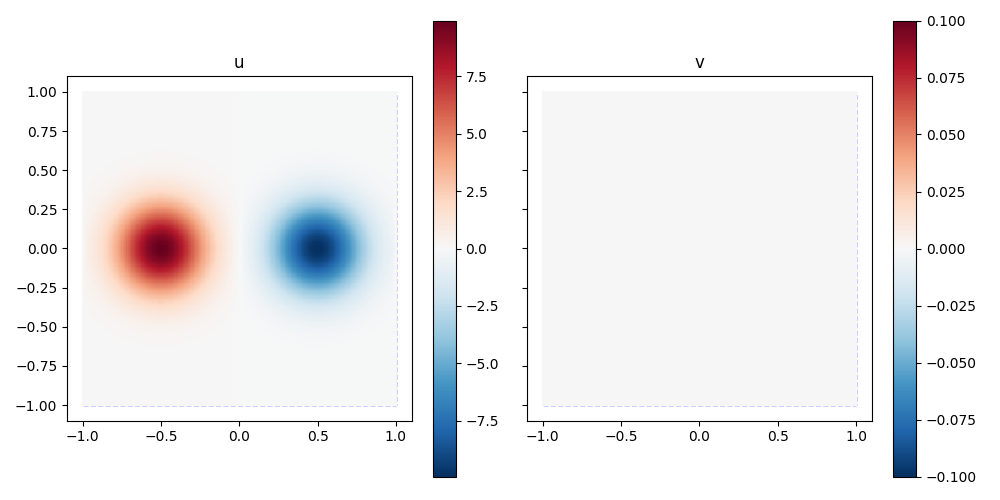

In [55]:
def copyWaveSystem(waveSystem):
    waveStateCopy = WaveEquationState(
        u = waveSystem.waveState.u.clone().detach(),
        v = waveSystem.waveState.v.clone().detach(),
        c = waveSystem.waveState.c.clone().detach(),
        damping = waveSystem.waveState.damping.clone().detach(),
    )
    return WaveSystem(
        systemState = waveSystem.systemState,
        waveState = waveStateCopy,
        neighborhood = waveSystem.neighborhood,
        t = waveSystem.t
    )

eulerIntegrator = getIntegrator(IntegrationSchemeType.explicitEuler)
RK4Integrator = getIntegrator(IntegrationSchemeType.rungeKutta4)

waveSystem_ = copyWaveSystem(waveSystem)

n = waveSystem.waveState.u.shape[0]
nx = int(n**0.5)
# print(f'Assuming square grid with nx={nx}, ny={nx}')
domainArea = (config['domain'].max[0] - config['domain'].min[0]) * (config['domain'].max[1] - config['domain'].min[1])
# print(f'Particle area: {domainArea/n}, particle spacing: {(domainArea/n)**0.5}')
dx = (domainArea/n)**0.5

dt = 0.02
cflNumber = max(args.obstacleSpeeds + [args.defaultSpeed]) * dt / dx

hMax = waveSystem_.systemState.supports.max().item()
print(f'Max wave speed: {waveSystem_.waveState.c.max().item():.4f}')
print(f'Max support radius: {hMax:.4f}')
print(f'CFL number (based on dx): {cflNumber:.4f} [dx={dx:.4f}, dt={dt:.4f}]')
print(f'CFL number (based on hMax): {max(args.obstacleSpeeds + [args.defaultSpeed]) * dt / hMax:.4f} [hMax={hMax:.4f}, dt={dt:.4f}]')


integrator = RK4Integrator
# integrator = eulerIntegrator

fig, axis, uPlot, vPlot, cPlot, dampPlot = plotState(
    particleState,
    smoothedState,
    config, kernel,
    markerSize = 0.5,
    plotGrid = True,
    plotCD = False)
# fig.savefig(f'output/{folderName}/initial_state.png', dpi = args.figureDpi)


In [57]:

export = True

################################################################################
#                                Run Simulation                                #
################################################################################

if verbose:
    print("Starting simulation...")

runSimulation(fig, particleState, uPlot, vPlot, waveSystem_, waveSystemFunction, integrator, nx, dt, 1024, kernel, config, False, plotInterval = 5, exportImages = True, umin = -5, umax = 5, vmin = -50, vmax = 50, prefix = prefix, timestamp = timestamp)

if verbose:
    print("Simulation complete.")

Starting simulation...


  0%|          | 0/1024 [00:00<?, ?it/s]

: 